
---

# AdaGrad — Easy but Detailed Guide

---

## 1. What is AdaGrad?

AdaGrad means **Adaptive Gradient**.
It is a way to train models where each parameter (weight) gets **its own learning rate** that changes over time.

* If a parameter often gets large gradients → its learning rate becomes smaller.
* If a parameter gets small or rare gradients → its learning rate stays bigger.

This is very useful for **sparse data** (data with many zeros), for example in natural language processing or recommendation systems.

---

## 2. The Main Idea

Normal Gradient Descent has **one learning rate for all parameters**.
AdaGrad remembers the **past squared gradients** for each parameter and divides the current gradient by the square root of that sum.

This means:

* Parameters that change a lot will slow down.
* Parameters that don’t change much will move faster.

---

## 3. The Formula

We keep an **accumulator** `s` for each parameter.

At step $t$:

1. $s_t = s_{t-1} + g_t^2$  (element by element)
2. $\theta_{t+1} = \theta_t - \eta \cdot \frac{g_t}{\sqrt{s_t} + \varepsilon}$

Where:

* $\theta$ = parameters (weights)
* $g_t$ = gradient at step $t$
* $\eta$ = starting learning rate
* $\varepsilon$ = small number to avoid division by zero

---

## 4. Why It’s Special

**Scale Invariance**:
If one feature is 100 times bigger than another, AdaGrad will automatically adjust so that both features are treated fairly.

**Sparse Data Friendly**:
Features that appear rarely will still get a big enough learning rate to learn quickly.

---

## 5. Example

Imagine we have 2 parameters:

Step 1: gradient = (10, 1) → $s = (100, 1)$
Step 2: gradient = (10, 0) → $s = (200, 1)$
Step 3: gradient = (10, 0) → $s = (300, 1)$

Parameter 1’s learning rate becomes small quickly (because it gets big gradients every time).
Parameter 2’s learning rate stays big (because it barely changes).

---

## 6. Strengths

* Works very well with text or other sparse data.
* No need to normalise features much.
* Has good mathematical guarantees for convex problems.

---

## 7. Weaknesses

* Learning rates keep getting smaller → training can become too slow later.
* Needs to store extra values (one number for each parameter).
* Often replaced in deep learning by RMSProp or Adam, which fix the slow-down problem.

---

## 8. Simple Pseudocode

```
initialize θ
s = 0 (same shape as θ)
for each step:
    g = gradient(θ)
    s = s + g*g
    θ = θ - η * g / (sqrt(s) + ε)
```

---

## 9. When to Use

✅ Sparse features (like one-hot encoding, bag-of-words)
✅ Recommendation systems
✅ As a strong baseline optimizer

❌ Very deep neural networks (better use AdamW or RMSProp)

---




##Elongated Problem when have sparse data

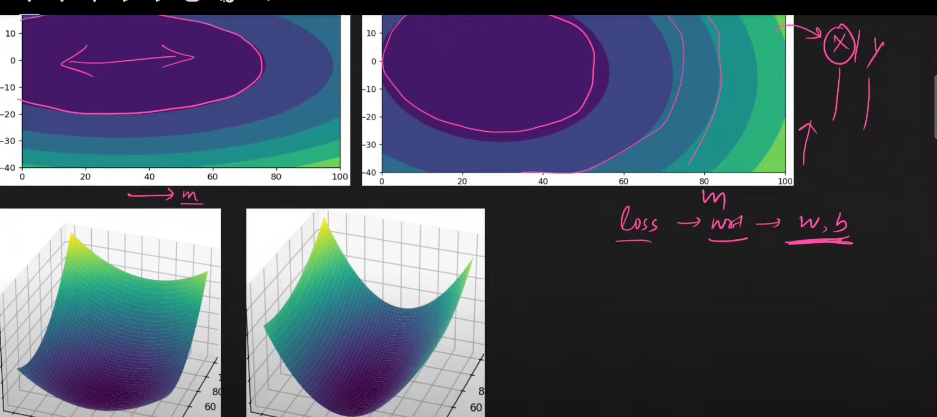

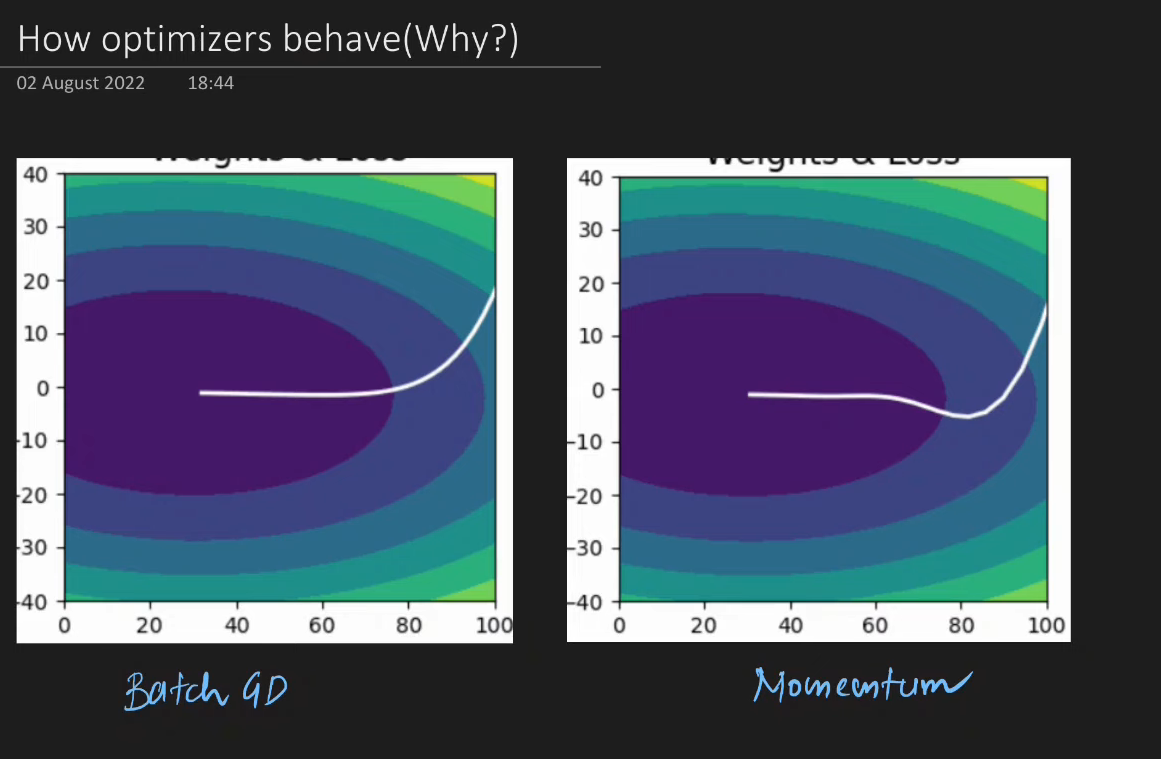

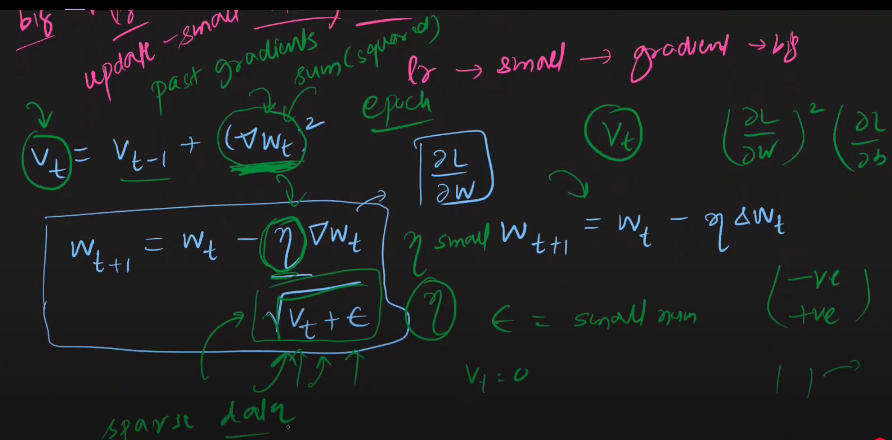



---

## 1. **The Accumulator $V_t$**

Formula:

$$
V_t = V_{t-1} + \left( \frac{\partial L}{\partial W_t} \right)^2
$$

* $V_t$ stores the **sum of past squared gradients** for each weight.
* Starts at $V_0 = 0$.
* Each epoch/step: add the current gradient squared to it.
* **Effect:** If a weight often gets big gradients, $V_t$ grows quickly.

---

## 2. **The Update Rule**

AdaGrad modifies the normal gradient descent:

$$
W_{t+1} = W_t - \frac{\eta}{\sqrt{V_t} + \varepsilon} \cdot \frac{\partial L}{\partial W_t}
$$

* $\eta$ = base learning rate.
* $\varepsilon$ = small number to avoid division by zero.
* **Division by $\sqrt{V_t} + \varepsilon$**:

  * If $V_t$ is large (many big gradients before) → denominator is large → **smaller step**.
  * If $V_t$ is small (few/small gradients before) → denominator is small → **larger step**.

---

## 3. **Effect on Each Value**

For **each parameter**:

1. If it changes a lot (large gradients many times):

   * $V_t$ big → learning rate shrinks for that parameter.
2. If it changes rarely (sparse data):

   * $V_t$ small → learning rate stays high → learns faster.
3. This adaptation is **independent** for each parameter — not a global adjustment.

---

## 4. **Why This Matters**

* Stops “zig-zagging” in directions with large gradient values.
* Speeds up learning in directions where gradients are small or rare.
* Very useful in **sparse data problems** where some features appear only in few samples.

---







---

## 🚀 Gist of AdaGrad

* **What it does**:
  Adapts the learning rate **for each parameter separately** based on the history of its gradients.
* **How it works**:

  1. Keep a running sum of **past squared gradients** for each parameter ($V_t$).
  2. Divide the current gradient by the square root of this sum + small $\varepsilon$.
  3. This makes the step size **smaller** for parameters with large past gradients, and **bigger** for parameters with small past gradients.
* **Why**:
  Helps with:

  * Different feature scales
  * Sparse features (most values are 0)
  * Avoiding overshooting in steep directions

---

## 📊 Simple Example

Let’s say we have **two parameters**: $w_1$ and $w_2$
Base learning rate $\eta = 0.1$, $\varepsilon = 1e{-8}$.

### Step 1:

Gradient: $g = (4, 1)$
$V = (0, 0)$ → $V = (16, 1)$
Update:

$$
w_1 \text{ step size} = 0.1 / \sqrt{16} = 0.025
$$

$$
w_2 \text{ step size} = 0.1 / \sqrt{1} = 0.1
$$

So $w_1$ moves less, $w_2$ moves more.

---

### Step 2:

Gradient: $g = (4, 0.5)$
$V = (32, 1.25)$

$$
w_1 \text{ step size} = 0.1 / \sqrt{32} \approx 0.0177
$$

$$
w_2 \text{ step size} = 0.1 / \sqrt{1.25} \approx 0.0894
$$

w₁’s rate is shrinking faster because it keeps getting large gradients.

---

## ❓ Important Q\&A

**Q: Why does AdaGrad help with sparse features?**
A: Rare features have small accumulated gradient sum → they keep a higher learning rate → learn faster.

**Q: Why add $\varepsilon$?**
A: To avoid division by zero and control very early step sizes.

**Q: What’s the main downside?**
A: Learning rates only shrink → after many steps, updates can become too small and learning stops.

**Q: How to fix the downside?**
A: Use RMSProp or Adam, which reset or decay the accumulator.

**Q: Do I still need to normalize features?**
A: AdaGrad is scale-invariant, but normalization still helps training stability.

---






 **cons / limitations of AdaGrad**:

---

### 1️⃣ **Learning rate keeps shrinking**

* In AdaGrad, the accumulator $s_t$ **only grows** over time.
* Effective learning rate = $\eta / \sqrt{s_t}$ → always decreases.
* After many updates, the learning rate can become **too small**, making training slow or stuck.
* This is the biggest reason RMSProp, Adam, and others were developed (they reset or decay $s_t$).

---

### 2️⃣ **Not ideal for non-convex deep learning**

* In deep neural nets, you often need a *constant* or *decaying* learning rate schedule — not a one-way shrink.
* AdaGrad can stop learning too early before escaping bad local minima or saddle points.

---

### 3️⃣ **Memory cost**

* Needs an extra accumulator $s_t$ **for every parameter** (same size as weights).
* For huge models (billions of params), this doubles memory usage.

---

### 4️⃣ **Sensitive to very large early gradients**

* If initial gradients are huge, $s_t$ grows quickly → learning rate drops too much early in training.
* Possible fix: gradient clipping or starting with smaller base $\eta$.

---

### 5️⃣ **No forgetting**

* AdaGrad treats all past gradients equally (no decay factor).
* In non-stationary problems (data distribution changes over time), this is bad — because old gradients keep influencing step size forever.

---

